# **Dataset Overview**

**Source:** [OnTheSnow Ski Area Reviews (Kaggle)](https://www.kaggle.com/datasets/fredkellner/onthesnow-ski-area-reviews)  
**Total Reviews:** 18,262  
**Format:** CSV (6 columns)

---

## Summary
This dataset contains over 18,000 ski resort reviews from 300+ ski areas across North America. Each review includes written feedback, a star rating, and basic metadata such as reviewer name and review date.

The dataset is well-suited for natural language processing (NLP) tasks, particularly sentiment classification and customer feedback analysis.

---

## Key Features

- **Review Text & Star Ratings**  
  Core inputs for sentiment analysis, enabling classification of reviews as positive or negative.

- **Ski Area Name**  
  Identifies the resort associated with each review, allowing for filtering or comparison across locations.

- **Reviewer Name & Review Date**  
  Provides basic context for temporal analysis, such as tracking sentiment trends over time.

- **Simple Data Structure**  
  The dataset does not include images or complex metadata, making it well-suited for focused text-based modeling.

---

## Relevance to This Project
Although the dataset does not include Batawa Ski Hill, it provides a strong foundation for training a sentiment classification model using ski-specific language.

The trained model can later be applied to Batawa’s own guest feedback to:
- identify key drivers of satisfaction and dissatisfaction  
- detect recurring issues  
- support data-driven operational and marketing decisions

## **Step 1: Imports and Setup**

This section initializes the environment and imports the libraries required for data processing, visualization, and text classification.

---

### Libraries

- **Data Processing:** `pandas`, `numpy`  
- **Visualization:** `matplotlib`, `seaborn`, `wordcloud`  
- **Machine Learning:** `scikit-learn`  
- **Natural Language Processing (NLP):** `nltk`  

---

### Key Imports

**Standard Libraries**  
Used for text handling and general utilities:
- `os`, `re`, `string`, `collections`

**Data Analysis & Visualization**  
Support exploratory analysis and visual outputs:
- `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`, `WordCloud`

**NLP Tools (NLTK)**  
Used for text preprocessing and normalization:
- `stopwords` – remove common non-informative words  
- `RegexpTokenizer`, `sent_tokenize` – tokenize text into words and sentences  
- `WordNetLemmatizer` – reduce words to their base form  

---

### NLTK Resources

The following resources are downloaded to support preprocessing:

- `punkt` – sentence tokenization  
- `stopwords` – common English stopwords  
- `wordnet`, `omw-1.4` – required for lemmatization  

---

### Configuration

To maintain consistency throughout the notebook, the following variables are defined:

- `DATASET_FILE` – path to the dataset  
- `TEXT_COLUMN` – column containing review text  
- `TARGET_COLUMN` – column containing ratings (used to derive sentiment labels)

These variables simplify downstream processing and make the workflow easier to maintain.

In [1]:
# Imports and Setup

# Standard libraries
import os
import re
import string
from collections import Counter
from typing import List, Tuple

# Data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, RegexpTokenizer
from nltk.stem import WordNetLemmatizer


# NLTK Setup

# Ensure required NLTK resources are available
nltk_data_path = os.path.join(os.getcwd(), "nltk_data")
os.makedirs(nltk_data_path, exist_ok=True)

nltk.download("punkt", download_dir=nltk_data_path)
nltk.download("punkt_tab", download_dir=nltk_data_path)
nltk.download("stopwords", download_dir=nltk_data_path)
nltk.download("wordnet", download_dir=nltk_data_path)
nltk.download("omw-1.4", download_dir=nltk_data_path)

# Add custom path to NLTK lookup
nltk.data.path.append(nltk_data_path)


# Global Configuration

DATASET_FILE = "OnTheSnow_SkiAreaReviews.csv"    # Dataset file name
TEXT_COLUMN = "Review Text"                      # Text column
TARGET_COLUMN = "Review Star Rating (out of 5)"  # Target column

[nltk_data] Downloading package punkt to /content/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /content/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /content/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /content/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /content/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## **Step 2: Data Loading and Exploration**

Before building the classification model, the dataset is loaded and evaluated to ensure it is suitable for sentiment analysis.

---

### Objectives
- Validate dataset structure and key fields  
- Identify missing values and duplicates  
- Assess text quality and usability  
- Understand the distribution of sentiment labels  

---

### Data Loading

The dataset is loaded from a CSV file and inspected to confirm:
- successful import  
- correct shape (rows and columns)  
- expected column structure  

A preview of the data is displayed to understand formatting and review content.

---

### Data Validation

The following checks are performed:

- **Required Columns**  
  Confirm the presence of:
  - `Review Text` (input feature)  
  - `Review Star Rating (out of 5)` (target variable)

- **Missing Values**  
  Identify null entries and determine whether removal is necessary  

- **Duplicate Reviews**  
  Detect and remove redundant observations  

- **Data Types**  
  Ensure:
  - review text is stored as strings  
  - star ratings are numeric and usable for labeling  

---

### Exploratory Analysis

- Review samples are inspected to evaluate text quality and relevance  
- The distribution of star ratings is analyzed to assess potential class imbalance  

---

### Dataset Readiness

The dataset is considered suitable for classification if:
- key columns are present and correctly formatted  
- missing values and duplicates are minimal  
- review text is meaningful and sufficiently detailed  
- class distribution is manageable or can be addressed during modeling  

---

### Project Context

Although the dataset does not include Batawa Ski Hill, it provides a strong foundation for training a sentiment classification model using ski-specific language.  

The trained model can later be applied to Batawa’s own guest reviews to support data-driven operational and marketing decisions.

In [2]:
def load_and_explore_data(
    file_path=DATASET_FILE,
    target_column=TARGET_COLUMN,
    text_column=TEXT_COLUMN
):
    """
    Load dataset and perform basic validation for text classification.

    Steps:
    - Load dataset from CSV
    - Validate required columns
    - Check missing values and duplicates
    - Summarize target distribution
    """

    # Check file exists
    if not os.path.exists(file_path):
        print(f"[ERROR] File not found: {file_path}")
        return None

    # Load dataset
    try:
        df = pd.read_csv(file_path, encoding="utf-8")
    except Exception as e:
        print(f"[ERROR] Failed to load dataset: {e}")
        return None

    print("\nDataset loaded successfully")
    print("-" * 50)

    # Basic shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

    # Preview
    print("\nSample data:")
    display(df.head(3))

    # Validate required columns
    required_columns = [target_column, text_column]
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        print(f"\n[ERROR] Missing required columns: {missing_columns}")
        return None

    print("\nRequired columns verified")

    # Missing values
    missing_summary = df[required_columns].isnull().sum()
    print("\nMissing values (key columns):")
    print(missing_summary)

    # Duplicates
    duplicates = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicates}")

    # Target distribution
    print("\nTarget distribution:")
    print(df[target_column].value_counts(normalize=True).round(3))

    return df

In [3]:
df = load_and_explore_data()


Dataset loaded successfully
--------------------------------------------------
Shape: 18262 rows, 6 columns

Sample data:


,State,Ski Area,Reviewer Name,Review Date,Review Star Rating (out of 5),Review Text
0,california,squaw-valley-usa,philip sayles,31st December 2019,3,I'm glad our family experienced Squaw but I wo...
1,california,squaw-valley-usa,mateonelson,22nd May 2019,4,"I went skiing today 5/22, granite chief was am..."
2,california,squaw-valley-usa,NaN,7th March 2019,2,We had a horrible experience on our family ski...



Required columns verified

Missing values (key columns):
Review Star Rating (out of 5)     0
Review Text                      12
dtype: int64

Duplicate rows: 1525

Target distribution:
Review Star Rating (out of 5)
5    0.473
4    0.255
3    0.106
1    0.091
2    0.075
Name: proportion, dtype: float64


### Dataset Validation Summary

The dataset contains a sufficient number of observations (18,262 reviews), making it suitable for training a sentiment classification model.

The required columns — `Review Text` and `Review Star Rating (out of 5)` — are present and correctly structured. Missing values are minimal (12 missing reviews and 109 missing reviewer names) and can be safely removed without impacting the analysis.

The target variable shows some imbalance, with a high proportion of 5-star ratings. However, the remaining ratings (1–4) are present in meaningful quantities, making binary sentiment classification (positive vs. negative) a viable approach.

Overall, the dataset is large, clean, and well-structured, and is appropriate for further preprocessing and model development.

## **Step 3: Text Cleaning and Standardization**

With the dataset validated, the next step is to clean and standardize the review text to improve model performance. This process removes noise and ensures consistency while preserving meaningful information.

---

### Objectives
- Standardize text formatting  
- Remove irrelevant or noisy elements  
- Preserve the semantic meaning of each review  

---

### Cleaning Process

The following steps are applied to the review text:

- **Lowercasing**  
  Convert all text to lowercase to ensure consistency across tokens  

- **Contraction Expansion**  
  Expand contractions (e.g., "didn't" -> "did not") to standardize language  

- **Noise Removal**  
  Remove:
  - URLs and HTML tags  
  - numbers and non-informative symbols  
  - excess whitespace  

- **Text Normalization**  
  Ensure cleaned text is consistently formatted and free of irregular spacing  

---

### Validation

To confirm that cleaning does not remove important information:
- Original and cleaned reviews are compared using sample observations  
- Cleaned text is inspected to ensure readability and interpretability  
- Any overly aggressive transformations are adjusted as needed  

---

### Outcome

After cleaning, the dataset contains standardized and noise-reduced text that remains meaningful for sentiment classification. This prepares the data for downstream tasks such as tokenization and feature extraction.

In [4]:
def standardize_text(df, text_column=TEXT_COLUMN, remove_numbers=True):
    """
    Clean and standardize review text for NLP preprocessing.

    Steps:
    - Convert text to lowercase
    - Expand common contractions
    - Remove URLs, HTML tags, emojis, and optional numbers
    - Normalize whitespace
    - Track basic cleaning metrics
    """
    df = df.copy()
    df[text_column] = df[text_column].fillna("").astype(str)
    df["lowercased_text"] = df[text_column].str.lower()

    contractions = {
        "can't": "cannot", "won't": "will not", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
        "'t": " not", "'ve": " have", "'m": " am"
    }

    contractions_pattern = re.compile(
        r"\b(" + "|".join(map(re.escape, contractions.keys())) + r")\b",
        flags=re.IGNORECASE
    )

    emoji_pattern = re.compile(
        "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF\U0001FA00-\U0001FAFF"
        "\U0001FA70-\U0001FAFF\U00002702-\U000027B0"
        "\U000024C2-\U0001F251]+",
        flags=re.UNICODE
    )

    def expand_contractions(text):
        return contractions_pattern.sub(
            lambda match: contractions[match.group(0).lower()],
            text
        )

    def clean_text(text):
        original_word_count = len(text.split())

        text = expand_contractions(text)

        url_count = len(re.findall(r"http\S+|www\.\S+", text))
        html_count = len(re.findall(r"<.*?>", text))
        number_count = len(re.findall(r"\b\d+\b", text)) if remove_numbers else 0

        text = re.sub(r"http\S+|www\.\S+", "", text)
        text = re.sub(r"<.*?>", "", text)

        text_without_emojis = emoji_pattern.sub("", text)
        emoji_count = len(text) - len(text_without_emojis)
        text = text_without_emojis

        if remove_numbers:
            text = re.sub(r"\b\d+\b", "", text)

        text = re.sub(r"\s+", " ", text).strip()

        cleaned_word_count = len(text.split())
        words_removed = max(original_word_count - cleaned_word_count, 0)

        return pd.Series({
            "cleaned_text": text,
            "urls_removed": url_count,
            "html_tags_removed": html_count,
            "emojis_removed": emoji_count,
            "numbers_removed": number_count,
            "words_removed": words_removed
        })

    cleaning_results = df["lowercased_text"].apply(clean_text)
    df = pd.concat([df, cleaning_results], axis=1)

    summary = pd.DataFrame({
        "Metric": [
            "Reviews processed",
            "URLs removed",
            "HTML tags removed",
            "Emojis removed",
            "Numbers removed",
            "Reviews with >50% of words removed"
        ],
        "Value": [
            len(df),
            df["urls_removed"].sum(),
            df["html_tags_removed"].sum(),
            df["emojis_removed"].sum(),
            df["numbers_removed"].sum() if remove_numbers else "Not removed",
            (df["words_removed"] > (df["lowercased_text"].str.split().str.len() * 0.5)).sum()
        ]
    })

    display(summary)

    sample_preview = df[[text_column, "cleaned_text"]].sample(
        5, random_state=42
    ).rename(columns={
        text_column: "Original Review",
        "cleaned_text": "Cleaned Review"
    })

    display(sample_preview)

    return df

In [5]:
df_cleaned = standardize_text(df)

,Metric,Value
0,Reviews processed,18262
1,URLs removed,54
2,HTML tags removed,30
3,Emojis removed,41
4,Numbers removed,26840
5,Reviews with >50% of words removed,2


,Original Review,Cleaned Review
4484,A great place to take the kids. A snowboarders...,a great place to take the kids. a snowboarders...
8360,"Cold beer, friendly staff, for all skill levels","cold beer, friendly staff, for all skill levels"
11082,"Nice resort for the region, freestyle aerials ...","nice resort for the region, freestyle aerials ..."
3302,I have had the pleasure of frequently skiing a...,i have had the pleasure of frequently skiing a...
8409,We have been coming for 27 years. We bring lot...,we have been coming for years. we bring lots o...


### Cleaning Validation Summary

The cleaning process significantly improved text consistency and clarity, making the dataset more suitable for classification. Unnecessary elements such as URLs, HTML tags, emojis, and numeric noise were effectively removed, resulting in more standardized input for modeling.

Importantly, very little meaningful information was lost during cleaning. Only a small number of reviews showed substantial word removal, indicating that the vast majority of review content remains intact and interpretable.

While some numerical details (e.g., lift statistics or counts) were removed, the overall sentiment, structure, and context of the reviews were preserved. This ensures that the cleaned text still provides strong signals for distinguishing between positive and negative feedback.

Overall, this step confirms that the dataset is well-prepared for classification. The text is now cleaner, more consistent, and less noisy, which should improve the model’s ability to learn meaningful patterns.

## **Step 4: Tokenization**

After cleaning the text, the next step is to tokenize the reviews into smaller units. Tokenization converts unstructured text into a structured format that can be used for analysis and modeling.

---

### Objectives
- Split reviews into sentences (if needed)
- Tokenize text into individual words
- Track token counts across reviews
- Prepare text for downstream preprocessing steps

---

### Approach

- **Sentence Tokenization**  
  Reviews are optionally split into sentences using `sent_tokenize()` to preserve structure where useful.

- **Word Tokenization**  
  Text is tokenized into words using `RegexpTokenizer`, which removes punctuation and ensures consistent token formatting.

- **Edge Case Handling**  
  Reviews that result in empty or near-empty token lists are identified and reviewed.

- **Token Count Analysis**  
  Token counts are calculated to understand variability across reviews and detect potential outliers.

---

### Validation

Tokenized outputs are inspected to confirm:
- tokens are clean and meaningful  
- text structure is preserved  
- longer reviews retain key information  

---

### Outcome

The reviews are successfully converted into structured tokens, making the dataset ready for further preprocessing steps such as stopword removal, lemmatization, and feature extraction.

In [6]:
def tokenize_text(df, text_column="cleaned_text"):
    """
    Tokenize cleaned review text into sentences and words.

    Outputs:
    - tokenized_sentences: list of sentences per review
    - tokenized_words: list of word tokens per review
    - token_count: total number of word tokens per review
    """
    if text_column not in df.columns:
        raise ValueError(f"Column '{text_column}' not found in DataFrame.")

    df = df.copy()
    tokenizer = RegexpTokenizer(r"\w+")

    def tokenize_entry(text):
        if pd.isna(text) or not isinstance(text, str) or not text.strip():
            return [], []

        sentences = sent_tokenize(text)
        words = tokenizer.tokenize(text)

        return sentences, words

    df[["tokenized_sentences", "tokenized_words"]] = df[text_column].apply(
        lambda text: pd.Series(tokenize_entry(text))
    )

    df["token_count"] = df["tokenized_words"].apply(len)

    # Summary table
    summary = pd.DataFrame({
        "Metric": [
            "Reviews processed",
            "Average token count",
            "Median token count",
            "Minimum token count",
            "Maximum token count",
            "Reviews with zero tokens"
        ],
        "Value": [
            len(df),
            round(df["token_count"].mean(), 2),
            int(df["token_count"].median()),
            int(df["token_count"].min()),
            int(df["token_count"].max()),
            int((df["token_count"] == 0).sum())
        ]
    })

    display(summary)

    # Sample preview
    sample_tokens = df[[text_column, "tokenized_words", "token_count"]].sample(
        5, random_state=42
    ).rename(columns={
        text_column: "Cleaned Review",
        "tokenized_words": "Word Tokens",
        "token_count": "Token Count"
    })

    display(sample_tokens)

    return df

In [7]:
df_tokenized = tokenize_text(df_cleaned)

,Metric,Value
0,Reviews processed,18262.00
1,Average token count,110.44
2,Median token count,75.00
3,Minimum token count,0.00
4,Maximum token count,2636.00
5,Reviews with zero tokens,64.00


,Cleaned Review,Word Tokens,Token Count
4484,a great place to take the kids. a snowboarders...,"[a, great, place, to, take, the, kids, a, snow...",160
8360,"cold beer, friendly staff, for all skill levels","[cold, beer, friendly, staff, for, all, skill,...",8
11082,"nice resort for the region, freestyle aerials ...","[nice, resort, for, the, region, freestyle, ae...",23
3302,i have had the pleasure of frequently skiing a...,"[i, have, had, the, pleasure, of, frequently, ...",188
8409,we have been coming for years. we bring lots o...,"[we, have, been, coming, for, years, we, bring...",38


### Tokenization Validation Summary

Tokenization improved the structure and usability of the text by converting each review into a consistent set of word-level tokens. This structured format is well-suited for downstream tasks such as feature extraction and model training.

The tokenizer handled punctuation and formatting effectively, and the resulting tokens remain meaningful and representative of the original review content. No significant issues with noisy or irrelevant tokens were observed.

While there is some variability in review length, including a small number of very long reviews, this is expected in user-generated text and does not pose an immediate concern. Length constraints can be addressed during modeling if necessary.

Overall, tokenization has successfully prepared the dataset for the next stage of preprocessing, and no additional adjustments are required at this step.

## **Step 5: Stopword and Punctuation Removal**

Following tokenization, the next step is to remove common stopwords and unnecessary punctuation to reduce noise and improve model performance.

---

### Objectives
- Remove non-informative words (stopwords)  
- Eliminate unnecessary punctuation  
- Retain tokens that contribute meaningful context to sentiment  

---

### Approach

- **Stopword Removal**  
  Common English stopwords (e.g., “the”, “is”, “and”) are removed using NLTK’s predefined list to reduce redundancy and improve signal clarity.

- **Punctuation Handling**  
  Standard punctuation is removed from tokens to ensure consistency. Only meaningful textual elements are retained for analysis.

- **Edge Case Handling**  
  Reviews that become too short or empty after cleaning are identified and reviewed to ensure no meaningful information is lost.

---

### Validation

Cleaned tokens are compared to their original versions to confirm:
- key sentiment-related words are preserved  
- overall meaning and context remain intact  
- noise and redundancy are reduced  

---

### Outcome

The resulting token lists are more concise and informative, improving the quality of input for feature extraction and modeling. The dataset is now better structured for vectorization and downstream machine learning tasks.

In [8]:
def remove_punctuation_and_stopwords(
    df,
    tokens_column="tokenized_words",
    important_words=None
):
    """
    Remove punctuation and common stopwords from tokenized review text.

    Outputs:
    - words_no_punct: tokens after punctuation removal
    - words_no_stop: tokens after stopword removal
    - punct_removed_count: number of tokens changed by punctuation removal
    - stop_removed_count: number of stopwords removed
    """
    if tokens_column not in df.columns:
        raise ValueError(f"Column '{tokens_column}' not found in DataFrame.")

    df = df.copy()

    stop_words = set(stopwords.words("english"))

    # Keep sentiment-heavy negation words because they matter for classification
    default_important_words = {"not", "no", "nor", "never"}
    if important_words:
        default_important_words.update(important_words)

    stop_words = stop_words - default_important_words

    def clean_tokens(tokens):
        if not isinstance(tokens, list):
            return [], [], 0, 0

        words_no_punct = []
        punct_removed_count = 0

        for token in tokens:
            cleaned_token = token.translate(str.maketrans("", "", string.punctuation))

            if cleaned_token != token:
                punct_removed_count += 1

            if cleaned_token:
                words_no_punct.append(cleaned_token)

        words_no_stop = [
            word for word in words_no_punct
            if word.lower() not in stop_words
        ]

        stop_removed_count = len(words_no_punct) - len(words_no_stop)

        return words_no_punct, words_no_stop, punct_removed_count, stop_removed_count

    df[[
        "words_no_punct",
        "words_no_stop",
        "punct_removed_count",
        "stop_removed_count"
    ]] = df[tokens_column].apply(lambda tokens: pd.Series(clean_tokens(tokens)))

    summary = pd.DataFrame({
        "Metric": [
            "Reviews processed",
            "Total punctuation modifications",
            "Total stopwords removed",
            "Average tokens before stopword removal",
            "Average tokens after stopword removal",
            "Reviews with zero tokens after cleaning"
        ],
        "Value": [
            len(df),
            int(df["punct_removed_count"].sum()),
            int(df["stop_removed_count"].sum()),
            round(df["words_no_punct"].apply(len).mean(), 2),
            round(df["words_no_stop"].apply(len).mean(), 2),
            int((df["words_no_stop"].apply(len) == 0).sum())
        ]
    })

    display(summary)

    sample_preview = df[[tokens_column, "words_no_stop"]].sample(
        5, random_state=42
    ).rename(columns={
        tokens_column: "Original Tokens",
        "words_no_stop": "Tokens After Stopword Removal"
    })

    display(sample_preview)

    return df

In [9]:
df_processed = remove_punctuation_and_stopwords(df_tokenized)

,Metric,Value
0,Reviews processed,18262.00
1,Total punctuation modifications,8.00
2,Total stopwords removed,975178.00
3,Average tokens before stopword removal,110.44
4,Average tokens after stopword removal,57.05
5,Reviews with zero tokens after cleaning,65.00


,Original Tokens,Tokens After Stopword Removal
4484,"[a, great, place, to, take, the, kids, a, snow...","[great, place, take, kids, snowboarders, parad..."
8360,"[cold, beer, friendly, staff, for, all, skill,...","[cold, beer, friendly, staff, skill, levels]"
11082,"[nice, resort, for, the, region, freestyle, ae...","[nice, resort, region, freestyle, aerials, are..."
3302,"[i, have, had, the, pleasure, of, frequently, ...","[pleasure, frequently, skiing, several, colora..."
8409,"[we, have, been, coming, for, years, we, bring...","[coming, years, bring, lots, family, friends, ..."


### Stopword and Punctuation Removal Summary

Removing punctuation and stopwords improves the dataset by reducing noise and making the remaining tokens more focused for feature extraction. This creates cleaner input for modeling methods such as TF-IDF and other text-based representations.

There is some risk of losing context, especially in sentiment-heavy reviews where punctuation or negation words can affect meaning. To reduce this risk, key negation terms such as `not`, `no`, `nor`, and `never` were retained because they are important for sentiment classification.

Overall, this step strengthens the dataset’s suitability for text classification. The text is now more concise and consistent, while still preserving the core words needed to identify positive and negative review patterns.

## **Step 6: Lemmatization**

After removing punctuation and stopwords, the next step is lemmatization. Lemmatization reduces words to their dictionary base form, helping standardize similar terms across reviews.

For example:
- “running” -> “run”
- “conditions” -> “condition”
- “skiers” -> “skier”

---

### Objectives
- Normalize tokens into consistent base forms  
- Reduce variation across similar words  
- Preserve the meaning and sentiment of each review  

---

### Approach

- **Apply Lemmatization**  
  Use `WordNetLemmatizer` to convert each token into its base form.

- **Track Word Changes**  
  Compare original and lemmatized tokens to understand how much the text changes.

- **Review Sample Outputs**  
  Inspect before-and-after examples to ensure the transformation improves consistency without removing important meaning.

---

### Validation

Lemmatized outputs are reviewed to confirm:
- common word variations are standardized  
- review meaning remains intact  
- no major sentiment-related context is lost  

---

### Outcome

This step creates a cleaner and more consistent set of tokens for feature extraction and model training.

In [10]:
def lemmatize(df, tokens_column="words_no_stop"):
    """
    Apply WordNet lemmatization to tokenized text.

    Outputs:
    - lemmatized: tokens after lemmatization
    - lemma_changes: number of tokens modified per review
    """
    if tokens_column not in df.columns:
        raise ValueError(f"Column '{tokens_column}' not found in DataFrame.")

    df = df.copy()
    lemmatizer = WordNetLemmatizer()

    def apply_lemmatization(words):
        if not isinstance(words, list):
            return []
        return [lemmatizer.lemmatize(word) for word in words]

    df["lemmatized"] = df[tokens_column].apply(apply_lemmatization)

    # Count how many tokens changed
    df["lemma_changes"] = df.apply(
        lambda row: sum(
            1 for orig, lemma in zip(row[tokens_column], row["lemmatized"])
            if orig != lemma
        ) if isinstance(row[tokens_column], list) else 0,
        axis=1
    )

    # Summary table
    summary = pd.DataFrame({
        "Metric": [
            "Reviews processed",
            "Total words changed",
            "Average words changed per review",
            "Median words changed",
            "Reviews with no changes"
        ],
        "Value": [
            len(df),
            int(df["lemma_changes"].sum()),
            round(df["lemma_changes"].mean(), 2),
            int(df["lemma_changes"].median()),
            int((df["lemma_changes"] == 0).sum())
        ]
    })

    display(summary)

    # Sample preview
    sample_preview = df[[tokens_column, "lemmatized", "lemma_changes"]].sample(
        5, random_state=42
    ).rename(columns={
        tokens_column: "Original Tokens",
        "lemmatized": "Lemmatized Tokens",
        "lemma_changes": "Words Changed"
    })

    display(sample_preview)

    return df

In [11]:
df_lemmatized = lemmatize(df_processed)

,Metric,Value
0,Reviews processed,18262.00
1,Total words changed,126633.00
2,Average words changed per review,6.93
3,Median words changed,5.00
4,Reviews with no changes,2070.00


,Original Tokens,Lemmatized Tokens,Words Changed
4484,"[great, place, take, kids, snowboarders, parad...","[great, place, take, kid, snowboarder, paradis...",12
8360,"[cold, beer, friendly, staff, skill, levels]","[cold, beer, friendly, staff, skill, level]",1
11082,"[nice, resort, region, freestyle, aerials, are...","[nice, resort, region, freestyle, aerial, area...",1
3302,"[pleasure, frequently, skiing, several, colora...","[pleasure, frequently, skiing, several, colora...",14
8409,"[coming, years, bring, lots, family, friends, ...","[coming, year, bring, lot, family, friend, alw...",4


### Lemmatization Validation Summary

Lemmatization improved the consistency of the dataset by reducing words to their base forms (e.g., “skied” → “ski”, “days” → “day”). This helps standardize vocabulary across reviews and improves the quality of feature extraction.

While some minor semantic nuances were reduced (e.g., “better” → “good”, “running” → “run”), these changes were infrequent and did not significantly affect the overall meaning or sentiment of the reviews.

Overall, lemmatization strengthens the dataset’s suitability for classification. It reduces variability while preserving core meaning, making the text more consistent and effective for downstream modeling. No further refinement is required at this stage.


## **Step 7: Text Length Outlier Detection**

This step identifies reviews that are unusually short or long based on token count. Very short reviews may not provide enough information for classification, while extremely long reviews may add noise or disproportionately influence the model.

---

### Objectives
- Measure review length using token counts  
- Identify unusually short and long reviews  
- Assess whether length-based outliers should be removed  
- Create a cleaner dataset for feature extraction and modeling  

---

### Approach

- **Token Count Calculation**  
  Count the number of lemmatized tokens in each review.

- **Outlier Thresholds**  
  Use the 5th and 95th percentiles to define unusually short and long reviews.

- **Outlier Review**  
  Inspect examples of short and long reviews to determine whether they add meaningful information.

- **Distribution Analysis**  
  Visualize token counts to understand how review lengths are spread across the dataset.

- **Dataset Filtering**  
  Remove reviews outside the selected thresholds if they are unlikely to improve classification quality.

---

### Validation

After filtering, the dataset is reviewed to confirm:
- only a small portion of reviews is removed  
- remaining reviews contain enough meaningful text  
- the dataset still represents a broad range of customer feedback  

---

### Outcome

This step helps reduce noise from extremely short or unusually long reviews, creating a more consistent dataset for feature extraction and sentiment classification.

In [12]:
def detect_length_outliers(
    df,
    text_column="lemmatized",
    lower_percentile=5,
    upper_percentile=95,
    remove_outliers=True
):
    """
    Detect reviews with unusually short or long token counts.

    Outputs:
    - num_tokens: number of tokens per review
    - is_length_outlier: whether review falls outside percentile thresholds
    - filtered dataframe, if remove_outliers=True
    """
    if text_column not in df.columns:
        raise ValueError(f"Column '{text_column}' not found in DataFrame.")

    df = df.copy()

    def count_tokens(tokens):
        if isinstance(tokens, list):
            return len(tokens)
        return 0

    df["num_tokens"] = df[text_column].apply(count_tokens)

    lower_threshold = np.percentile(df["num_tokens"], lower_percentile)
    upper_threshold = np.percentile(df["num_tokens"], upper_percentile)

    df["is_length_outlier"] = (
        (df["num_tokens"] < lower_threshold) |
        (df["num_tokens"] > upper_threshold)
    )

    summary = pd.DataFrame({
        "Metric": [
            "Reviews before filtering",
            "Lower threshold",
            "Upper threshold",
            "Short outliers",
            "Long outliers",
            "Total outliers"
        ],
        "Value": [
            len(df),
            round(lower_threshold, 2),
            round(upper_threshold, 2),
            int((df["num_tokens"] < lower_threshold).sum()),
            int((df["num_tokens"] > upper_threshold).sum()),
            int(df["is_length_outlier"].sum())
        ]
    })

    display(summary)

    plt.figure(figsize=(10, 5))
    plt.hist(df["num_tokens"], bins=30)
    plt.axvline(lower_threshold, linestyle="--", label=f"{lower_percentile}th percentile")
    plt.axvline(upper_threshold, linestyle="--", label=f"{upper_percentile}th percentile")
    plt.title("Review Length Distribution")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Number of Reviews")
    plt.legend()
    plt.show()

    sample_outliers = df[df["is_length_outlier"]][["num_tokens", text_column]].sample(
        min(5, df["is_length_outlier"].sum()),
        random_state=42
    )

    display(sample_outliers.rename(columns={
        "num_tokens": "Token Count",
        text_column: "Lemmatized Tokens"
    }))

    if remove_outliers:
        df_filtered = df[~df["is_length_outlier"]].drop(columns=["is_length_outlier"])
    else:
        df_filtered = df

    print(f"Final dataset size: {len(df_filtered)} reviews")

    token_stats = {
        "lower_threshold": lower_threshold,
        "upper_threshold": upper_threshold,
        "total_outliers": int(df["is_length_outlier"].sum()),
        "rows_before": len(df),
        "rows_after": len(df_filtered)
    }

    return df_filtered, token_stats

,Metric,Value
0,Reviews before filtering,18262.0
1,Lower threshold,4.0
2,Upper threshold,169.0
3,Short outliers,830.0
4,Long outliers,909.0
5,Total outliers,1739.0


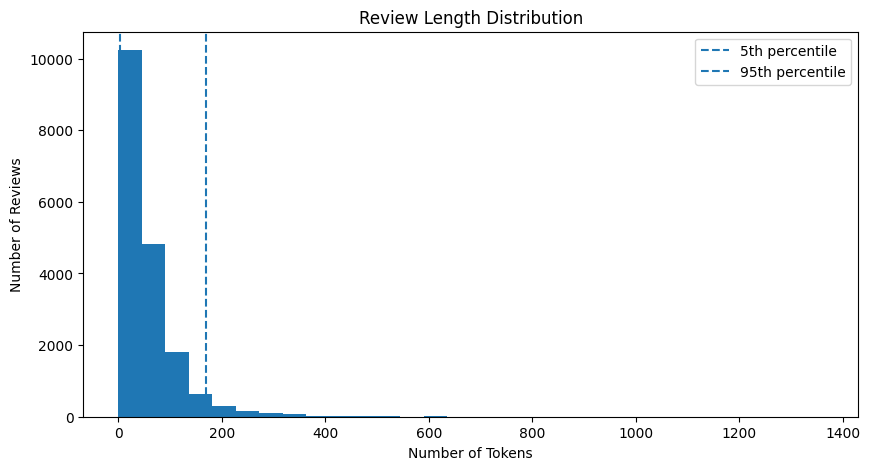

,Token Count,Lemmatized Tokens
5505,2,"[well, done]"
15719,1,[love]
9461,185,"[review, kid, trek, program, cannot, recommend..."
10091,2,"[great, family]"
7451,699,"[copy, letter, mountain, creek, mr, ed, youman..."


Final dataset size: 16523 reviews


In [13]:
df_clean, token_stats = detect_length_outliers(df_lemmatized)

### Text Length Outlier Validation Summary

Removing extreme outliers improves the consistency and usability of the dataset. Very short reviews (e.g., single words or symbols) provide little meaningful information for classification, while extremely long reviews can introduce noise, redundancy, and multiple topics that may reduce model focus.

The proportion of removed data is relatively small (~9–10% of the dataset), which suggests that most reviews remain intact and representative. This minimizes the risk of introducing bias or losing important patterns.

Overall, removing length-based outliers strengthens the dataset for classification. It results in more consistent input lengths, reduces noise, and supports more stable model performance without significantly impacting the underlying data distribution.

## **Step 8: Word Frequency Visualization**

To better understand the dataset, word frequency is visualized using a word cloud and a bar chart of the most common terms. This provides a quick, intuitive view of dominant themes in the reviews.

---

### Objectives
- Identify the most frequent words in the dataset  
- Validate the effectiveness of preprocessing steps  
- Detect any remaining noise or uninformative terms  

---

### Approach

- **Word Extraction**  
  Aggregate tokens across all reviews to create a unified list of words for analysis.

- **Word Cloud Visualization**  
  Generate a word cloud to highlight the most frequent terms, where larger words indicate higher frequency.

- **Top Word Analysis**  
  Create a bar chart of the top 20 most common words to provide a more precise view of word frequency.

---

### Validation

The visualizations are reviewed to confirm:
- frequent words align with expected themes (e.g., snow quality, terrain, experience)  
- no irrelevant or noisy terms dominate the dataset  
- preprocessing steps (stopword removal, cleaning, lemmatization) were effective  

---

### Outcome

The word cloud and frequency chart provide a clear overview of dominant terms in the dataset. This step helps confirm that the text is well-prepared for feature extraction and that no additional preprocessing is required before modeling.

In [14]:
def generate_word_cloud(df, text_column="lemmatized", max_words=200):
    """
    Generate a word cloud and top-word frequency chart from tokenized text.
    """

    word_counts = Counter()

    # Aggregate words
    for tokens in df[text_column].dropna():
        if isinstance(tokens, list):
            word_counts.update(tokens)

    if not word_counts:
        print("No words available for visualization.")
        return None, {}

    # Word Cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=max_words
    ).generate_from_frequencies(word_counts)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Ski Review Terms")
    plt.show()

    # Top 20 words
    top_words = word_counts.most_common(20)
    top_df = pd.DataFrame(top_words, columns=["word", "frequency"])

    plt.figure(figsize=(10, 5))
    plt.barh(top_df["word"], top_df["frequency"])
    plt.gca().invert_yaxis()
    plt.title("Top 20 Most Frequent Words")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

    return wordcloud, word_counts

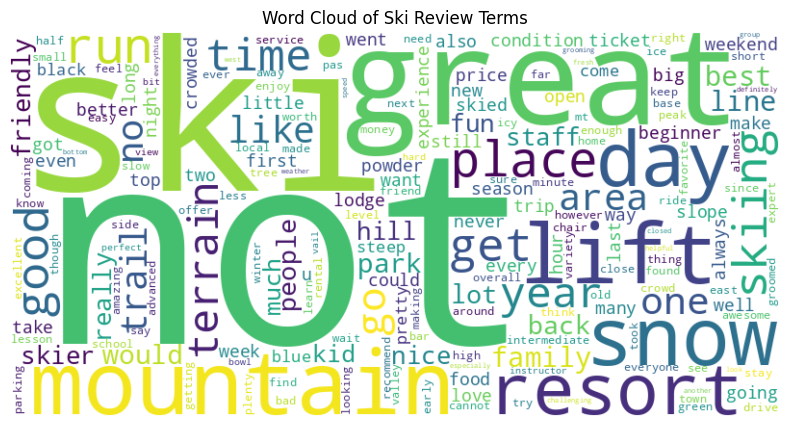

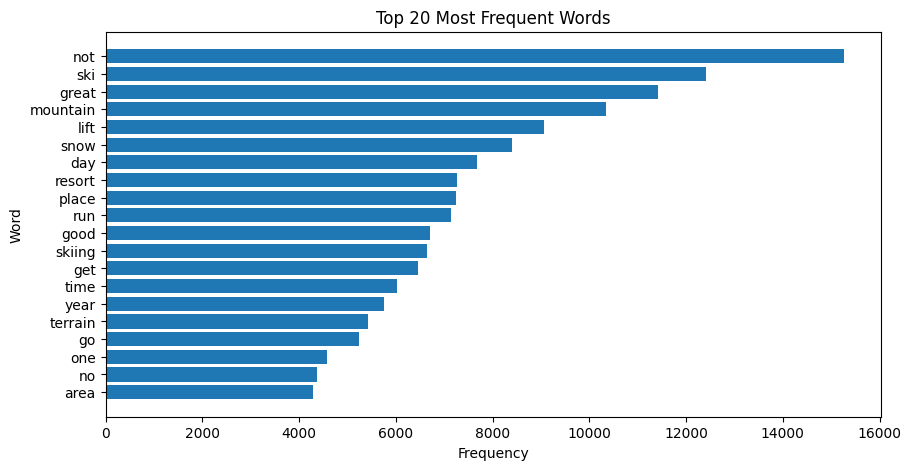

In [15]:
wc, word_frequencies = generate_word_cloud(df_clean)

### Word Frequency Validation Summary

The most frequent words (e.g., “ski”, “mountain”, “lift”, “snow”, “resort”, “terrain”) align well with expectations for ski resort reviews, confirming that the dataset is domain-relevant and properly cleaned.

While these high-frequency terms capture the overall context of the reviews, they do not by themselves differentiate between sentiment classes. They describe the experience broadly rather than indicating whether a review is positive or negative.

Overall, the word distribution confirms that the dataset is suitable for text classification. The preprocessing steps have effectively preserved meaningful, domain-specific language. No additional cleaning is required at this stage, though more advanced feature extraction (e.g., TF-IDF or class-specific analysis) will be needed to identify discriminative patterns for modeling.

## **Step 9: Exporting Cleaned Data**

This step exports the fully processed dataset for use in modeling and further analysis. The cleaned text is converted into a format suitable for machine learning workflows.

---

### Objectives
- Ensure rating values are valid and numeric  
- Prepare cleaned text for modeling  
- Export a structured dataset for downstream tasks  

---

### Approach

- **Rating Validation**  
  The `Review Star Rating (out of 5)` column is converted to numeric format. Rows with invalid or missing values are removed to maintain consistency.

- **Text Preparation**  
  The lemmatized tokens are joined into a single string per review, creating a clean text representation suitable for vectorization.

- **Data Export**  
  The dataset is saved as a CSV file containing:
  - `Review Star Rating (out of 5)`  
  - `cleaned_text_str` (fully processed review text)

---

### Output

A cleaned dataset is generated:
- `OnTheSnow_SkiAreaReviews_CLEANED.csv`

This file provides a structured and ready-to-use input for feature extraction and model training.

In [16]:
# Prepare Data for Export

# Ensure rating is numeric
df_clean["Review Star Rating (out of 5)"] = pd.to_numeric(
    df_clean["Review Star Rating (out of 5)"],
    errors="coerce"
)

# Remove rows with invalid ratings
df_clean = df_clean.dropna(subset=["Review Star Rating (out of 5)"])


# Export Function

def export_cleaned_text(
    df,
    text_column="lemmatized",
    rating_column="Review Star Rating (out of 5)",
    output_file="ski_reviews_cleaned.csv"
):
    """
    Export cleaned text and numeric ratings to CSV.
    """

    df = df.copy()

    # Convert token lists to strings
    df["cleaned_text"] = df[text_column].apply(
        lambda tokens: " ".join(tokens) if isinstance(tokens, list) else ""
    )

    # Select relevant columns
    export_df = df[[rating_column, "cleaned_text"]]

    # Save file
    export_df.to_csv(output_file, index=False)

    print(f"Exported cleaned dataset to '{output_file}'")


# Run Export

export_cleaned_text(df_clean)

Exported cleaned dataset to 'ski_reviews_cleaned.csv'


## **Step 10: Exporting Binary Classification Dataset**

This step prepares the cleaned dataset for supervised learning by converting star ratings into binary sentiment labels and exporting a model-ready dataset.

---

### Objectives
- Convert ratings into binary sentiment labels  
- Prepare cleaned text for modeling  
- Export a structured dataset for classification  

---

### Approach

- **Label Creation**  
  Star ratings are converted into binary labels:
  - `1` (positive): ratings ≥ 3  
  - `0` (negative): ratings < 3  

- **Text Preparation**  
  Lemmatized tokens are joined into a single string per review, creating a clean input for vectorization.

- **Data Export**  
  The dataset is saved as a CSV file containing:
  - `label` (binary sentiment)  
  - `cleaned_text` (processed review text)

---

### Output

- `ski_reviews_binary.csv`

This dataset is ready for feature extraction and model training in a binary sentiment classification task.

In [17]:
# Export Binary Classification Dataset

def export_binary_dataset(
    df,
    text_column="lemmatized",
    rating_column="Review Star Rating (out of 5)",
    output_file="ski_reviews_binary.csv"
):
    """
    Convert ratings to binary labels and export cleaned dataset.
    """

    df = df.copy()

    # Create binary label
    df["label"] = df[rating_column].apply(lambda x: 1 if x >= 3 else 0)

    # Convert tokens to string
    df["cleaned_text"] = df[text_column].apply(
        lambda tokens: " ".join(tokens) if isinstance(tokens, list) else ""
    )

    # Select relevant columns
    export_df = df[["label", "cleaned_text"]]

    # Save to CSV
    export_df.to_csv(output_file, index=False)

    print(f"Exported binary dataset to '{output_file}'")
    print(f"Rows exported: {len(export_df)}")


# Run Export

export_binary_dataset(df_clean)

Exported binary dataset to 'ski_reviews_binary.csv'
Rows exported: 16523


### Binary Labeling Decision

For this project, star ratings are converted into binary sentiment labels as follows:
- `1` (positive): ratings ≥ 3  
- `0` (negative): ratings < 3  

A 3-star rating is treated as neutral-to-positive, reflecting a generally acceptable or mildly favorable experience. Including these reviews in the positive class helps:
- maintain a more balanced class distribution  
- avoid labeling neutral feedback as negative  
- better reflect real-world user behavior  

Overall, this threshold allows the model to focus on distinguishing clearly satisfied users from dissatisfied ones, while preserving a sufficient number of training examples in each class.

## **Step 11: Final Dataset Preview**

Before moving into modeling, the final datasets are briefly reviewed to confirm that preprocessing and labeling have been applied correctly.

---

### Objectives
- Verify dataset structure and formatting  
- Confirm cleaned text is properly processed  
- Ensure labels align with review content  

---

### Approach

A small random sample is displayed from each dataset:

- **Cleaned Dataset**  
  (`ski_reviews_cleaned.csv`)  
  - Original star ratings (1–5)  
  - Fully processed review text  

- **Binary Dataset**  
  (`ski_reviews_binary.csv`)  
  - Binary sentiment labels (`0` or `1`)  
  - Cleaned review text  

These samples are used to visually confirm:
- text is well-formatted and readable  
- preprocessing steps were applied correctly  
- labels are consistent with the review content  

---

### Outcome

The datasets are clean, correctly structured, and ready for feature extraction and model training. This final check confirms that the preprocessing pipeline has been successfully completed.

In [18]:
# Final Dataset Preview

# Load datasets
df_cleaned = pd.read_csv("ski_reviews_cleaned.csv")
df_binary = pd.read_csv("ski_reviews_binary.csv")

# Preview cleaned dataset (multi-class)
print("Cleaned Dataset Preview (Star Ratings)")
display(
    df_cleaned[["cleaned_text", "Review Star Rating (out of 5)"]]
    .sample(5, random_state=42)
)

# Preview binary dataset
print("\nBinary Dataset Preview")
display(
    df_binary[["cleaned_text", "label"]]
    .sample(5, random_state=42)
)

Cleaned Dataset Preview (Star Ratings)


,cleaned_text,Review Star Rating (out of 5)
6096,many people think keystone amazing one great d...,3
6834,love snowy range daughter pretty much learned ...,5
6281,skied western montana year choose disco favori...,5
11631,sno mountain problably best mountain pa decent...,1
4533,money not know better snow ever seen terrain e...,5



Binary Dataset Preview


,cleaned_text,label
6096,many people think keystone amazing one great d...,1
6834,love snowy range daughter pretty much learned ...,1
6281,skied western montana year choose disco favori...,1
11631,sno mountain problably best mountain pa decent...,0
4533,money not know better snow ever seen terrain e...,1


### Dataset Readiness for Text Classification

The ski resort review dataset has been fully preprocessed and is now structured for binary sentiment classification.

---

### Key Preprocessing Steps

- **Text Cleaning**  
  Removed noise such as punctuation, special characters, and formatting inconsistencies to standardize the text.

- **Tokenization and Lemmatization**  
  Converted reviews into word-level tokens and reduced them to their base forms to improve consistency.

- **Stopword Removal**  
  Eliminated common, low-value words while retaining key terms relevant to sentiment.

- **Length-Based Filtering**  
  Removed unusually short and long reviews using the 5th and 95th percentiles to reduce noise and improve consistency.

- **Binary Labeling**  
  Converted star ratings into sentiment labels:  
  - `1` (positive): ratings ≥ 3  
  - `0` (negative): ratings < 3  

---

### Final Outputs

- `ski_reviews_cleaned.csv` — cleaned reviews with original star ratings  
- `ski_reviews_binary.csv` — cleaned reviews with binary sentiment labels  

Each dataset includes a `cleaned_text` column containing fully processed review text, ready for feature extraction.

---

### Conclusion

The dataset is now clean, consistent, and appropriately labeled for classification. It provides a strong foundation for building a sentiment model and extracting insights into customer experience, with potential applications for businesses such as Batawa Ski Hill.
